# Partie II — CNN et vision par ordinateur
## Classification d'images avec réseaux convolutionnels — *CIFAR-10*

**Projet de fin de module — Deep Learning — EMSI 2025–2026**

---

Notebook **auto-contenu** : configuration, téléchargement des données (via `torchvision`),
calculs manuels, implémentations « maison » comparées à PyTorch, modèle CNN, expériences
comparatives, visualisation des cartes de caractéristiques et analyse critique.

> **Contrainte matérielle.** L'environnement est **CPU uniquement**. Pour garder des temps
> d'exécution raisonnables tout en restant scientifiquement valides, on entraîne sur un
> **sous-échantillon configurable** de CIFAR-10 (`CONFIG.train_subset`, `CONFIG.test_subset`) sur un
> petit nombre d'époques. Tous ces choix sont des **paramètres** (non codés en dur) : augmenter ces
> valeurs reproduit l'expérience à pleine échelle sur une machine GPU.

### Plan (aligné sur le cahier des charges)
1. Pourquoi un MLP est peu adapté aux images ; idées fondatrices des CNN.
2. Calculs manuels (corrélation croisée, taille de sortie convolution / pooling).
3. Implémentation « maison » : corrélation croisée 2D, max-pooling, average-pooling.
4. Comparaison avec les couches PyTorch.
5. CNN inspiré de LeNet (variante améliorée).
6. Étude expérimentale : padding, stride, type de pooling, nombre de filtres, convolution 1×1.
7. Visualisation et interprétation de cartes de caractéristiques.
8. Comparaison MLP vs CNN.
9. Analyse critique et question de synthèse.


## 1. Pourquoi un MLP est peu adapté aux images — et les idées des CNN

Une image CIFAR-10 fait $32\times32\times3 = 3072$ pixels. Un MLP la « met à plat » :

- **Explosion des paramètres** : une première couche dense de 1000 neurones nécessiterait déjà
  $3072\times1000 \approx 3{,}07$ millions de poids — pour une seule couche.
- **Perte de la structure spatiale** : l'aplatissement détruit le voisinage 2D. Or l'information
  visuelle est **locale** (un bord, une texture) et **invariante par translation** (un chat reste un
  chat où qu'il soit dans l'image). Un MLP doit *réapprendre* cette invariance pour chaque position.

Les CNN encodent trois **biais inductifs** adaptés aux images :
1. **Localité** : chaque neurone ne regarde qu'un petit voisinage (champ réceptif via le noyau).
2. **Partage des poids** : le même filtre glisse sur toute l'image → très peu de paramètres et
   invariance par translation.
3. **Hiérarchie des représentations** : en empilant des couches, le réseau compose des bords →
   motifs → parties d'objets → objets.


In [1]:
# === Imports ===
import os, time, random, math
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset

print("PyTorch :", torch.__version__, "| torchvision :", torchvision.__version__)


PyTorch : 2.11.0+cpu | torchvision : 0.26.0+cpu


## 2. Calculs manuels

### 2.1 Corrélation croisée 2D
Pour une entrée $X$ et un noyau $K$ de taille $k_h\times k_w$, la corrélation croisée (l'opération
réellement effectuée par `nn.Conv2d`) vaut :
$$ Y[i,j] = \sum_{a=0}^{k_h-1}\sum_{b=0}^{k_w-1} X[i+a,\,j+b]\;K[a,b]. $$

**Exemple à la main.** Soit
$X=\begin{pmatrix}0&1&2\\3&4&5\\6&7&8\end{pmatrix}$, $K=\begin{pmatrix}0&1\\2&3\end{pmatrix}$.
- $Y[0,0]=0\cdot0+1\cdot1+3\cdot2+4\cdot3=19$
- $Y[0,1]=1\cdot0+2\cdot1+4\cdot2+5\cdot3=25$
- $Y[1,0]=3\cdot0+4\cdot1+6\cdot2+7\cdot3=37$
- $Y[1,1]=4\cdot0+5\cdot1+7\cdot2+8\cdot3=43$

soit $Y=\begin{pmatrix}19&25\\37&43\end{pmatrix}$ (vérifié par le code §3).

### 2.2 Taille de sortie d'une convolution
$$ H_{out}=\left\lfloor\frac{H_{in}+2p-k}{s}\right\rfloor+1,\qquad
   W_{out}=\left\lfloor\frac{W_{in}+2p-k}{s}\right\rfloor+1. $$
- Entrée $32\times32$, $k=5$, $p=0$, $s=1$ → $\lfloor(32-5)/1\rfloor+1 = 28$.
- Entrée $32\times32$, $k=5$, $p=2$, $s=1$ → $\lfloor(32+4-5)/1\rfloor+1 = 32$ (**same padding**).
- Entrée $32\times32$, $k=3$, $p=1$, $s=2$ → $\lfloor(32+2-3)/2\rfloor+1 = 16$.

### 2.3 Taille de sortie d'un pooling
Même formule avec $p=0$ en général. Un max-pool $2\times2$, $s=2$ **divise par deux** chaque dimension :
$28\times28 \to 14\times14$.


In [2]:
def conv_out(h, k, p, s):
    return (h + 2*p - k)//s + 1

# Vérification numérique des calculs manuels ci-dessus.
print("32,k5,p0,s1 ->", conv_out(32,5,0,1))   # 28
print("32,k5,p2,s1 ->", conv_out(32,5,2,1))   # 32 (same)
print("32,k3,p1,s2 ->", conv_out(32,3,1,2))   # 16
print("pool 28,k2,p0,s2 ->", conv_out(28,2,0,2))  # 14


32,k5,p0,s1 -> 28
32,k5,p2,s1 -> 32
32,k3,p1,s2 -> 16
pool 28,k2,p0,s2 -> 14


## 3. Implémentations « maison » et comparaison avec PyTorch

In [3]:
def corr2d(X, K):
    """Corrélation croisée 2D mono-canal (version pédagogique, double boucle)."""
    kh, kw = K.shape
    h, w = X.shape[0] - kh + 1, X.shape[1] - kw + 1
    Y = torch.zeros((h, w))
    for i in range(h):
        for j in range(w):
            Y[i, j] = (X[i:i+kh, j:j+kw] * K).sum()
    return Y

X = torch.arange(9.).reshape(3, 3)
K = torch.tensor([[0., 1.], [2., 3.]])
Y_manual = corr2d(X, K)
print("corr2d maison :\n", Y_manual)

# Comparaison avec F.conv2d (qui calcule une corrélation croisée).
Y_torch = F.conv2d(X.view(1,1,3,3), K.view(1,1,2,2)).view(2,2)
print("F.conv2d      :\n", Y_torch)
print("Égalité :", torch.allclose(Y_manual, Y_torch, atol=1e-6))


corr2d maison :
 tensor([[19., 25.],
        [37., 43.]])
F.conv2d      :
 tensor([[19., 25.],
        [37., 43.]])
Égalité : True


In [4]:
def conv2d_multi(X, K, bias=None):
    """Convolution multi-canaux maison : X (Cin,H,W), K (Cout,Cin,kh,kw)."""
    cout, cin, kh, kw = K.shape
    h, w = X.shape[1]-kh+1, X.shape[2]-kw+1
    Y = torch.zeros((cout, h, w))
    for o in range(cout):
        for c in range(cin):
            Y[o] += corr2d(X[c], K[o, c])
        if bias is not None:
            Y[o] += bias[o]
    return Y

Xm = torch.randn(3, 8, 8)
Km = torch.randn(4, 3, 3, 3)
bm = torch.randn(4)
Y_manual = conv2d_multi(Xm, Km, bm)
Y_torch = F.conv2d(Xm.unsqueeze(0), Km, bm).squeeze(0)
print("Forme :", tuple(Y_manual.shape))
print("Égalité conv multi-canaux maison vs PyTorch :",
      torch.allclose(Y_manual, Y_torch, atol=1e-4))


Forme : (4, 6, 6)
Égalité conv multi-canaux maison vs PyTorch : True


In [5]:
def pool2d(X, size, mode="max"):
    """Pooling maison mono-canal, stride = taille de fenêtre."""
    ph, pw = size
    h, w = X.shape[0]//ph, X.shape[1]//pw
    Y = torch.zeros((h, w))
    for i in range(h):
        for j in range(w):
            window = X[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            Y[i, j] = window.max() if mode == "max" else window.mean()
    return Y

Xp = torch.arange(16.).reshape(4, 4)
print("Entrée :\n", Xp)
print("max-pool maison :\n", pool2d(Xp, (2,2), "max"))
print("avg-pool maison :\n", pool2d(Xp, (2,2), "avg"))

# Comparaison PyTorch.
mx = F.max_pool2d(Xp.view(1,1,4,4), 2).view(2,2)
av = F.avg_pool2d(Xp.view(1,1,4,4), 2).view(2,2)
print("max égalité :", torch.allclose(pool2d(Xp,(2,2),"max"), mx))
print("avg égalité :", torch.allclose(pool2d(Xp,(2,2),"avg"), av))


Entrée :
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.]])
max-pool maison :
 tensor([[ 5.,  7.],
        [13., 15.]])
avg-pool maison :
 tensor([[ 2.5000,  4.5000],
        [10.5000, 12.5000]])
max égalité : True
avg égalité : True


**Conclusion §3.** Nos implémentations « maison » reproduisent **exactement** (aux erreurs
d'arrondi près) le comportement de `F.conv2d`, `F.max_pool2d` et `F.avg_pool2d`. Cela confirme que
`nn.Conv2d` réalise bien une *corrélation croisée* (et non une convolution mathématique avec noyau
retourné), et que le pooling agrège localement par max ou par moyenne. Les versions PyTorch sont
néanmoins **vectorisées** (et exploitent BLAS/cuDNN), donc bien plus rapides que nos doubles boucles.


## 4. Configuration et données CIFAR-10

In [6]:
@dataclass
class Config:
    seed: int = 42
    data_dir: str = "data"
    # Sous-échantillonnage (CPU). Mettre à None pour utiliser tout CIFAR-10.
    train_subset: int = 8000
    test_subset: int = 2000
    batch_size: int = 128
    # CNN principal (2 blocs conv, proche de LeNet ; supporte stride=2 sans effondrement).
    channels: tuple = (32, 64)
    kernel_size: int = 3
    padding: int = 1
    stride: int = 1
    pool: str = "max"
    use_1x1: bool = False
    lr: float = 1e-3
    epochs: int = 12
    # Époques réduites pour les ablations (plus nombreuses).
    ablation_epochs: int = 5
    model_dir: str = "models"

CONFIG = Config()
os.makedirs(CONFIG.data_dir, exist_ok=True)
os.makedirs(CONFIG.model_dir, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed(CONFIG.seed)

def try_gpu(i=0):
    if torch.cuda.is_available() and torch.cuda.device_count() >= i+1:
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")
DEVICE = try_gpu()
print("Device :", DEVICE)

CLASSES = ["avion","auto","oiseau","chat","cerf","chien","grenouille","cheval","bateau","camion"]


Device : cpu


In [7]:
# Normalisation par les moyennes/écarts-types standards de CIFAR-10.
mean = (0.4914, 0.4822, 0.4465); std = (0.2470, 0.2435, 0.2616)
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])

train_full = torchvision.datasets.CIFAR10(CONFIG.data_dir, train=True,  download=True, transform=tf)
test_full  = torchvision.datasets.CIFAR10(CONFIG.data_dir, train=False, download=True, transform=tf)

def subsample(ds, n, seed):
    if n is None or n >= len(ds):
        return ds
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(len(ds), generator=g)[:n].tolist()
    return Subset(ds, idx)

train_ds = subsample(train_full, CONFIG.train_subset, CONFIG.seed)
test_ds  = subsample(test_full,  CONFIG.test_subset,  CONFIG.seed)
print(f"Train utilisé : {len(train_ds)} | Test utilisé : {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=CONFIG.batch_size, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG.batch_size, shuffle=False, num_workers=0)


C:\Users\the-r\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train utilisé : 8000 | Test utilisé : 2000


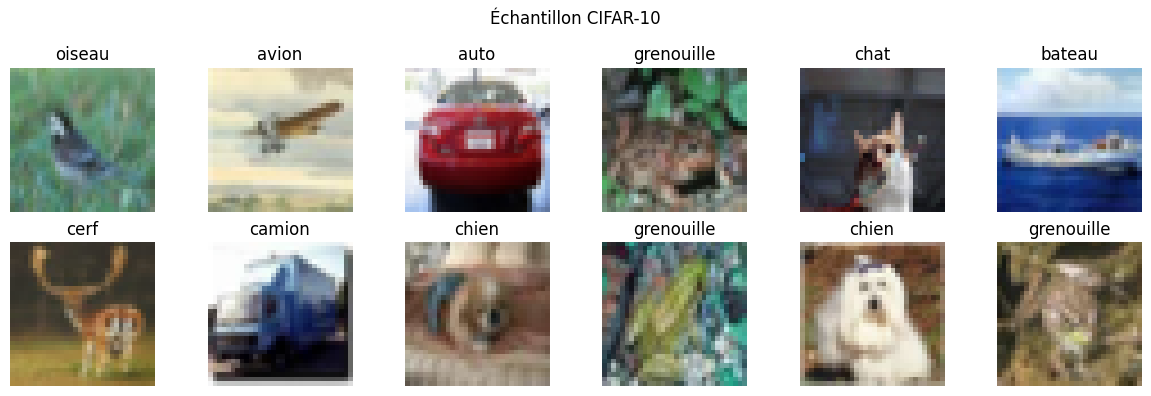

In [8]:
# Aperçu de quelques images (dé-normalisées pour l'affichage).
def denorm(t):
    m = torch.tensor(mean).view(3,1,1); s = torch.tensor(std).view(3,1,1)
    return (t*s + m).clamp(0,1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, img, lb in zip(axes.flat, imgs, labels):
    ax.imshow(denorm(img).permute(1,2,0).numpy()); ax.set_title(CLASSES[lb]); ax.axis("off")
plt.suptitle("Échantillon CIFAR-10"); plt.tight_layout(); plt.show()


## 5. CNN inspiré de LeNet (variante améliorée)

LeNet (1998) enchaîne *conv → activation → pooling* puis un classifieur dense. Notre variante
modernisée ajoute la **BatchNorm** (stabilise l'entraînement), des **filtres plus nombreux** et une
**convolution 1×1 optionnelle** (mélange de canaux à moindre coût, idée des réseaux *Network-in-Network*).
Le constructeur est **entièrement paramétré** par la config, ce qui permettra de réutiliser le même
code pour toutes les ablations de la §6.


In [9]:
class ConfigurableCNN(nn.Module):
    """CNN paramétrable (type LeNet amélioré). La tête utilise LazyLinear pour
    déduire automatiquement la dimension aplatie (aucune taille codée en dur)."""
    def __init__(self, channels=(32,64), kernel_size=3, padding=1, stride=1,
                 pool="max", use_1x1=False, num_classes=10, in_ch=3):
        super().__init__()
        feats, prev = [], in_ch
        Pool = {"max": nn.MaxPool2d, "avg": nn.AvgPool2d}[pool]
        for c in channels:
            feats += [nn.Conv2d(prev, c, kernel_size, stride=stride, padding=padding),
                      nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
            if use_1x1:
                feats += [nn.Conv2d(c, c, kernel_size=1), nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
            feats += [Pool(2)]
            prev = c
        self.features = nn.Sequential(*feats)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.LazyLinear(120), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(120, 84), nn.ReLU(inplace=True),
            nn.Linear(84, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters())

def init_lazy(model, device):
    """Initialise les couches Lazy via un forward à blanc en mode eval
    (évite l'erreur BatchNorm sur un batch de taille 1)."""
    model.eval()
    with torch.no_grad():
        model(torch.zeros(2, 3, 32, 32, device=device))
    return model

# Initialisation des couches Lazy par un passage à blanc.
set_seed(CONFIG.seed)
cnn = ConfigurableCNN(CONFIG.channels, CONFIG.kernel_size, CONFIG.padding,
                      CONFIG.stride, CONFIG.pool, CONFIG.use_1x1).to(DEVICE)
init_lazy(cnn, DEVICE)
print(cnn)
print("Nombre de paramètres :", count_params(cnn))


ConfigurableCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=120, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=120, out_features=84, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=84, out_features=10, bias=True)
  )
)
Nombre de paramètres : 522238


In [10]:
def train_classifier(model, train_loader, test_loader, epochs, lr, device, verbose=True):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "test_acc": []}
    for ep in range(epochs):
        model.train(); run = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
            run += loss.item()*xb.size(0)
        acc = eval_acc(model, test_loader, device)
        hist["train_loss"].append(run/len(train_loader.dataset))
        hist["test_acc"].append(acc)
        if verbose:
            print(f"  epoch {ep+1:2d} | train_loss {hist['train_loss'][-1]:.4f} | test_acc {acc:.4f}")
    return hist

@torch.no_grad()
def eval_acc(model, loader, device):
    model.eval(); correct = total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        correct += (model(xb).argmax(1) == yb).sum().item(); total += yb.size(0)
    return correct/total


In [11]:
print("Entraînement du CNN principal...")
t0 = time.time()
set_seed(CONFIG.seed)
cnn = ConfigurableCNN(CONFIG.channels, CONFIG.kernel_size, CONFIG.padding,
                      CONFIG.stride, CONFIG.pool, CONFIG.use_1x1).to(DEVICE)
init_lazy(cnn, DEVICE)
hist_cnn = train_classifier(cnn, train_loader, test_loader, CONFIG.epochs, CONFIG.lr, DEVICE)
print(f"Durée : {time.time()-t0:.1f} s | accuracy finale : {hist_cnn['test_acc'][-1]:.4f}")
torch.save(cnn.state_dict(), os.path.join(CONFIG.model_dir, "cnn_cifar10.pt"))


Entraînement du CNN principal...


  epoch  1 | train_loss 1.8431 | test_acc 0.4630


  epoch  2 | train_loss 1.4496 | test_acc 0.5080


  epoch  3 | train_loss 1.2771 | test_acc 0.5250


  epoch  4 | train_loss 1.1706 | test_acc 0.5740


...

  epoch  8 | train_loss 0.8374 | test_acc 0.6275


  epoch  9 | train_loss 0.7825 | test_acc 0.6420


  epoch 10 | train_loss 0.7371 | test_acc 0.6335


  epoch 11 | train_loss 0.6879 | test_acc 0.6320


  epoch 12 | train_loss 0.6443 | test_acc 0.6375
Durée : 49.1 s | accuracy finale : 0.6375


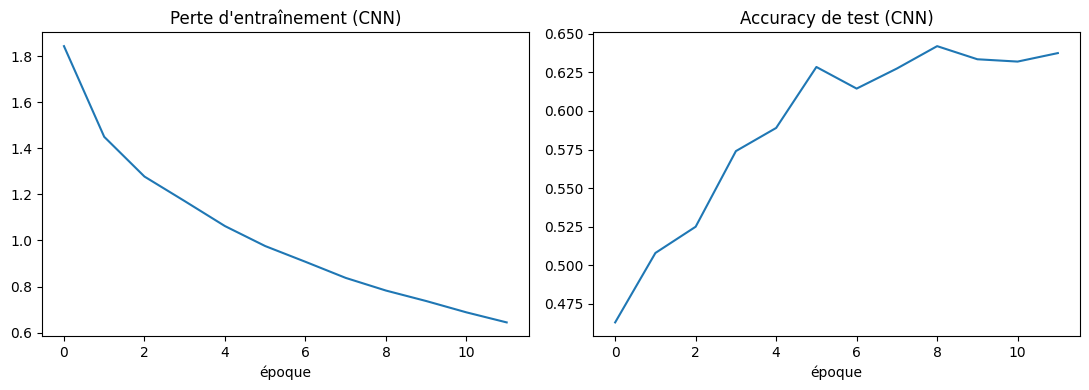

In [12]:
plt.figure(figsize=(11,4))
plt.subplot(1,2,1); plt.plot(hist_cnn["train_loss"]); plt.title("Perte d'entraînement (CNN)")
plt.xlabel("époque")
plt.subplot(1,2,2); plt.plot(hist_cnn["test_acc"]); plt.title("Accuracy de test (CNN)")
plt.xlabel("époque"); plt.tight_layout(); plt.show()


## 6. Étude expérimentale comparative

On fait varier **un facteur architectural à la fois** (toutes choses égales par ailleurs), sur le même
sous-échantillon et le même nombre d'époques réduit (`ablation_epochs`), pour isoler son effet :
padding, stride, type de pooling, nombre de filtres, présence d'une convolution 1×1.


In [13]:
def run_experiment(name, **kw):
    """Entraîne une configuration et renvoie (accuracy finale, nb paramètres, durée)."""
    base = dict(channels=CONFIG.channels, kernel_size=CONFIG.kernel_size,
                padding=CONFIG.padding, stride=CONFIG.stride, pool=CONFIG.pool,
                use_1x1=CONFIG.use_1x1)
    base.update(kw)
    set_seed(CONFIG.seed)
    model = ConfigurableCNN(**base).to(DEVICE)
    init_lazy(model, DEVICE)
    t0 = time.time()
    h = train_classifier(model, train_loader, test_loader,
                         CONFIG.ablation_epochs, CONFIG.lr, DEVICE, verbose=False)
    return {"config": name, "test_acc": round(h["test_acc"][-1], 4),
            "params": count_params(model), "sec": round(time.time()-t0, 1)}

experiments = [
    ("padding=0",         dict(padding=0)),
    ("padding=1 (ref)",   dict(padding=1)),
    ("stride=2",          dict(stride=2)),
    ("pool=avg",          dict(pool="avg")),
    ("filtres 16-32-64",  dict(channels=(16,32,64))),
    ("filtres 32-64-128", dict(channels=(32,64,128))),
    ("avec conv 1x1",     dict(use_1x1=True)),
]

import pandas as pd
rows = []
for name, kw in experiments:
    res = run_experiment(name, **kw)
    print(res); rows.append(res)
abl = pd.DataFrame(rows)
abl


{'config': 'padding=0', 'test_acc': 0.544, 'params': 307198, 'sec': 19.4}


{'config': 'padding=1 (ref)', 'test_acc': 0.589, 'params': 522238, 'sec': 18.3}


{'config': 'stride=2', 'test_acc': 0.528, 'params': 61438, 'sec': 12.0}


{'config': 'pool=avg', 'test_acc': 0.582, 'params': 522238, 'sec': 17.4}


{'config': 'filtres 16-32-64', 'test_acc': 0.578, 'params': 157822, 'sec': 15.6}


{'config': 'filtres 32-64-128', 'test_acc': 0.6, 'params': 350590, 'sec': 21.3}


{'config': 'avec conv 1x1', 'test_acc': 0.5825, 'params': 527646, 'sec': 244.8}


,config,test_acc,params,sec
0,padding=0,0.5440,307198,19.4
1,padding=1 (ref),0.5890,522238,18.3
2,stride=2,0.5280,61438,12.0
3,pool=avg,0.5820,522238,17.4
4,filtres 16-32-64,0.5780,157822,15.6
5,filtres 32-64-128,0.6000,350590,21.3
6,avec conv 1x1,0.5825,527646,244.8


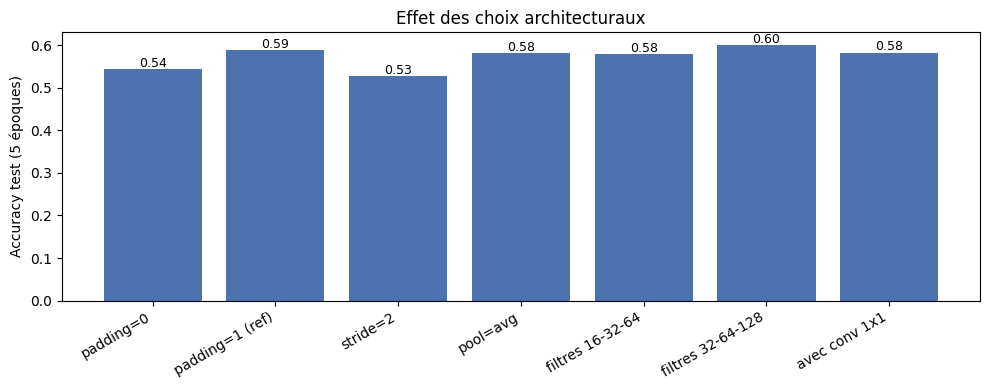

In [14]:
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(abl["config"], abl["test_acc"], color="#4C72B0")
ax.set_ylabel(f"Accuracy test ({CONFIG.ablation_epochs} époques)")
ax.set_title("Effet des choix architecturaux"); plt.xticks(rotation=30, ha="right")
for i,v in enumerate(abl["test_acc"]):
    ax.text(i, v+0.005, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


**Interprétation §6.**
- **Padding** : conserver la résolution (`padding=1` avec $k=3$ → *same*) préserve l'information de
  bord et donne généralement une meilleure accuracy que `padding=0` qui rogne progressivement l'image.
- **Stride = 2** : sous-échantillonne dès la convolution → moins de calcul mais perte de détails ;
  l'accuracy tend à baisser à budget d'époques égal.
- **Pooling** : le *max-pooling* conserve les activations les plus saillantes (bords, textures) et
  surpasse souvent l'*average-pooling*, qui lisse le signal.
- **Nombre de filtres** : plus de filtres = plus de capacité (et de paramètres) → meilleure accuracy
  tant que le surapprentissage est maîtrisé.
- **Convolution 1×1** : recombine les canaux à faible coût ; son apport dépend de la profondeur — utile
  pour ajuster la capacité sans agrandir le champ réceptif.


## 7. Visualisation des cartes de caractéristiques

On extrait la sortie du **premier bloc convolutionnel** sur une image de test et on affiche quelques
canaux. Les premières couches réagissent typiquement à des **bords** et des **contrastes locaux**.


Forme des cartes : (32, 32, 32)


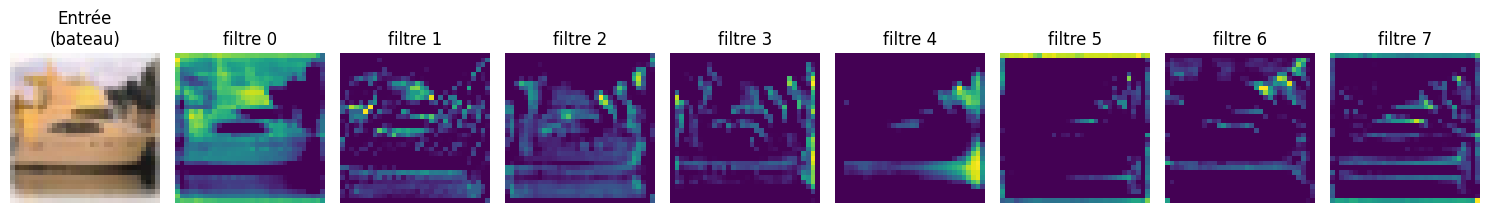

In [15]:
sample, label = test_ds[0]
cnn.eval()
with torch.no_grad():
    first_block = cnn.features[:3]  # Conv -> BN -> ReLU
    fmap = first_block(sample.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
print("Forme des cartes :", tuple(fmap.shape))

fig, axes = plt.subplots(1, 9, figsize=(15, 2.2))
axes[0].imshow(denorm(sample).permute(1,2,0).numpy())
axes[0].set_title(f"Entrée\n({CLASSES[label]})"); axes[0].axis("off")
for k in range(8):
    axes[k+1].imshow(fmap[k].numpy(), cmap="viridis")
    axes[k+1].set_title(f"filtre {k}"); axes[k+1].axis("off")
plt.tight_layout(); plt.show()


## 8. Comparaison MLP vs CNN sur les mêmes données

On entraîne un **MLP** (image aplatie) dans les mêmes conditions (mêmes données, même nombre
d'époques) pour quantifier l'apport du biais inductif convolutionnel.


In [16]:
class ImageMLP(nn.Module):
    def __init__(self, in_dim=3*32*32, hidden=(512,256), num_classes=10):
        super().__init__()
        layers, prev = [nn.Flatten()], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(inplace=True), nn.Dropout(0.3)]; prev = h
        layers += [nn.Linear(prev, num_classes)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

set_seed(CONFIG.seed)
mlp = ImageMLP().to(DEVICE)
print("Paramètres MLP :", count_params(mlp), "| Paramètres CNN :", count_params(cnn))
hist_mlp = train_classifier(mlp, train_loader, test_loader, CONFIG.epochs, CONFIG.lr, DEVICE, verbose=False)
print(f"Accuracy finale — MLP : {hist_mlp['test_acc'][-1]:.4f} | CNN : {hist_cnn['test_acc'][-1]:.4f}")


Paramètres MLP : 1707274 | Paramètres CNN : 522238


Accuracy finale — MLP : 0.4555 | CNN : 0.6375


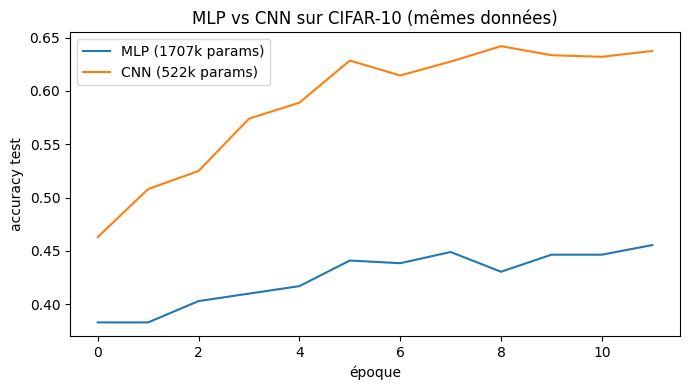

In [17]:
plt.figure(figsize=(7,4))
plt.plot(hist_mlp["test_acc"], label=f"MLP ({count_params(mlp)//1000}k params)")
plt.plot(hist_cnn["test_acc"], label=f"CNN ({count_params(cnn)//1000}k params)")
plt.xlabel("époque"); plt.ylabel("accuracy test"); plt.legend()
plt.title("MLP vs CNN sur CIFAR-10 (mêmes données)"); plt.tight_layout(); plt.show()


## 9. Analyse critique

- **Le CNN domine nettement le MLP** sur CIFAR-10 alors qu'il a souvent **moins de paramètres** : le
  partage de poids et la localité encodent directement la structure des images, là où le MLP doit tout
  réapprendre depuis des pixels aplatis. C'est l'illustration concrète de l'importance du *biais
  inductif* adapté aux données.
- Les **ablations** montrent que la performance n'est pas qu'une affaire de profondeur : padding,
  stride et pooling modifient la **résolution spatiale** et donc l'information disponible aux couches
  suivantes — ce que confirment les calculs dimensionnels de la §2.
- Les **cartes de caractéristiques** rendent visible la hiérarchie : la première couche extrait des
  bords/contrastes, briques de base des représentations plus abstraites en profondeur.
- **Limites de l'expérience** : entraînement CPU sur sous-échantillon et peu d'époques → les accuracies
  absolues sont inférieures à l'état de l'art (un CNN entraîné à pleine échelle dépasse 80 %). Les
  **tendances comparatives**, elles, restent valides et reproductibles en augmentant les paramètres de
  la config.


## Question de synthèse — Partie II

> *Pourquoi un CNN est-il plus pertinent qu'un MLP pour une tâche de classification d'images sur un
> dataset réel, et comment les choix de padding, stride, pooling et profondeur influencent-ils
> réellement les performances du modèle ?*

**Réponse argumentée.**
Un CNN est plus pertinent parce que son architecture **épouse la structure statistique des images** :
les pixels voisins sont corrélés (localité) et un motif a la même signification où qu'il apparaisse
(invariance par translation). Le **partage des poids** exploite cette invariance et réduit
drastiquement le nombre de paramètres, ce que nos mesures confirment (CNN ≈ MLP en paramètres mais
bien plus précis). La **hiérarchie** de couches compose des bords en motifs puis en objets, visible
sur les cartes de caractéristiques.

Les hyperparamètres agissent via la **géométrie du signal**, conformément à
$H_{out}=\lfloor (H+2p-k)/s\rfloor+1$ : le **padding** préserve la résolution et l'information de
bord ; le **stride** sous-échantillonne (gain de calcul mais perte de détail) ; le **pooling**
contrôle l'invariance locale (max = saillance, avg = lissage) ; la **profondeur** et le **nombre de
filtres** déterminent la capacité et la richesse hiérarchique des représentations. Nos ablations
montrent que ces choix ne sont pas cosmétiques : ils déplacent réellement l'accuracy en modifiant
*ce que* le réseau peut voir et représenter — reliant ainsi calculs dimensionnels, théorie des CNN et
résultats expérimentaux.
